In [10]:
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
df_train = pd.read_csv("cs-training.csv")
df_test = pd.read_csv("cs-test.csv")
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [13]:
df_train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


C:\Users\mutyl\AppData\Local\Temp\ipykernel_9544\4217944997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SeriousDlqin2yrs", data=df_train, palette=["#4C9BE8", "#E85C5C"], ax=ax)


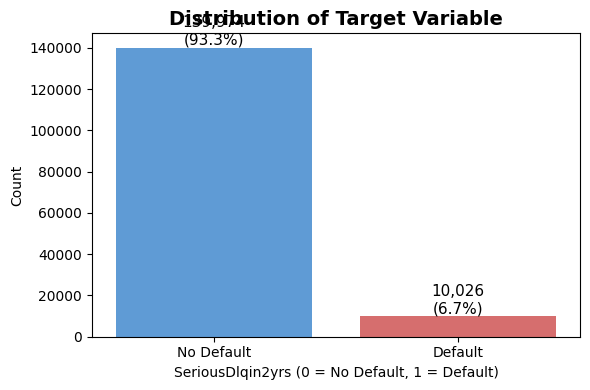

Default Rate: 0.0668


In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_train["SeriousDlqin2yrs"].value_counts().sort_index()
sns.countplot(x="SeriousDlqin2yrs", data=df_train, palette=["#4C9BE8", "#E85C5C"], ax=ax)
ax.set_title("Distribution of Target Variable", fontsize=14, fontweight="bold")
ax.set_xlabel("SeriousDlqin2yrs (0 = No Default, 1 = Default)")
ax.set_ylabel("Count")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Default", "Default"])
for p in ax.patches:
    pct = p.get_height() / len(df_train) * 100
    ax.annotate(f"{int(p.get_height()):,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()
print("Default Rate: {:.4f}".format(df_train["SeriousDlqin2yrs"].sum() / len(df_train)))

In [15]:
null_val_sums = df_train.isnull().sum()
pd.DataFrame({"Column": null_val_sums.index, "Number of Null Values": null_val_sums.values,
             "Proportion": null_val_sums.values / len(df_train) })

,Column,Number of Null Values,Proportion
0,Unnamed: 0,0,0.000000
1,SeriousDlqin2yrs,0,0.000000
2,RevolvingUtilizationOfUnsecuredLines,0,0.000000
3,age,0,0.000000
4,NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
5,DebtRatio,0,0.000000
6,MonthlyIncome,29731,0.198207
7,NumberOfOpenCreditLinesAndLoans,0,0.000000
8,NumberOfTimes90DaysLate,0,0.000000
9,NumberRealEstateLoansOrLines,0,0.000000


In [16]:
df_train["RevolvingUtilizationOfUnsecuredLines"].describe()

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

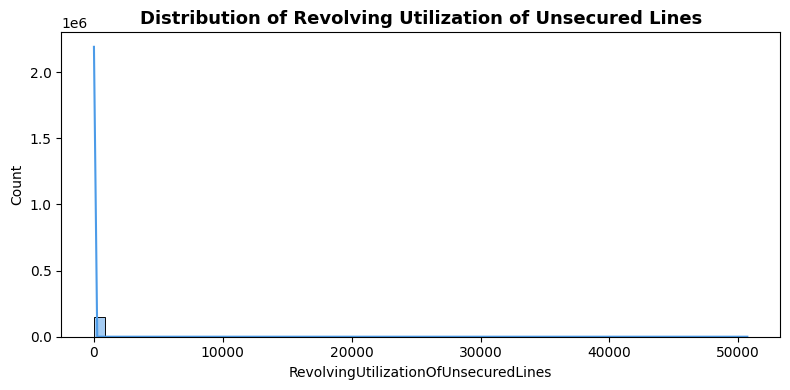

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_train["RevolvingUtilizationOfUnsecuredLines"], kde=True, bins=60, color="#4C9BE8", ax=ax)
ax.set_title("Distribution of Revolving Utilization of Unsecured Lines", fontsize=13, fontweight="bold")
ax.set_xlabel("RevolvingUtilizationOfUnsecuredLines")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [18]:
default_prop = []
for i in range(int(df_train["RevolvingUtilizationOfUnsecuredLines"].max())):
    temp_ = df_train.loc[df_train["RevolvingUtilizationOfUnsecuredLines"] >= i]
    default_prop.append([i, temp_["SeriousDlqin2yrs"].mean()])
default_prop

[[0, np.float64(0.06684)],
 [1, np.float64(0.37177950868783705)],
 [2, np.float64(0.14555256064690028)],
 [3, np.float64(0.09931506849315068)],
 [4, np.float64(0.08679245283018867)],
 [5, np.float64(0.07874015748031496)],
 [6, np.float64(0.07692307692307693)],
 [7, np.float64(0.0778688524590164)],
 [8, np.float64(0.07407407407407407)],
 [9, np.float64(0.07053941908713693)],
 [10, np.float64(0.07053941908713693)],
 [11, np.float64(0.07053941908713693)],
 [12, np.float64(0.06666666666666667)],
 [13, np.float64(0.058823529411764705)],
 [14, np.float64(0.058823529411764705)],
 [15, np.float64(0.05531914893617021)],
 [16, np.float64(0.05531914893617021)],
 [17, np.float64(0.05531914893617021)],
 [18, np.float64(0.05531914893617021)],
 [19, np.float64(0.05555555555555555)],
 [20, np.float64(0.05555555555555555)],
 [21, np.float64(0.05555555555555555)],
 [22, np.float64(0.05555555555555555)],
 [23, np.float64(0.05555555555555555)],
 [24, np.float64(0.05555555555555555)],
 [25, np.float64(0.05

Text(0.5, 1.0, 'Proportion of Defaulters As Minimum RUUL Increases')

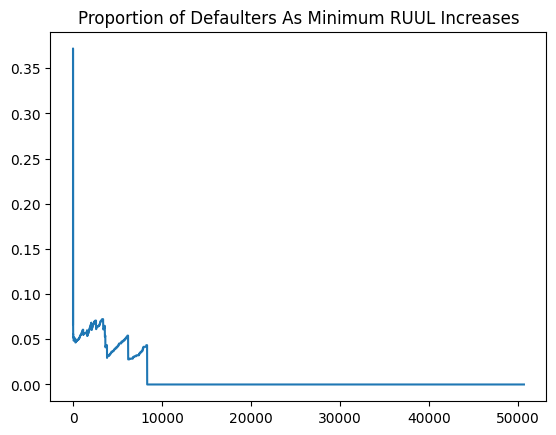

In [19]:
sns.lineplot(x=[i[0] for i in default_prop], y=[i[1] for i in default_prop])
plt.title("Proportion of Defaulters As Minimum RUUL Increases")

In [20]:
print("Proportion of Defaulters with Total Amount of Money Owed Not Exceeding Total Credit Limit: {}"\
     .format(df_train.loc[(df_train["RevolvingUtilizationOfUnsecuredLines"] >= 0) & (df_train["RevolvingUtilizationOfUnsecuredLines"] <= 1)]["SeriousDlqin2yrs"].mean()))

Proportion of Defaulters with Total Amount of Money Owed Not Exceeding Total Credit Limit: 0.05991996127598361


In [21]:
print("Proportion of Defaulters with Total Amount of Money Owed Not Exceeding or Equal to 13 times of Total Credit Limit:\n{}"\
     .format(df_train.loc[(df_train["RevolvingUtilizationOfUnsecuredLines"] >= 0) & (df_train["RevolvingUtilizationOfUnsecuredLines"] < 13)]["SeriousDlqin2yrs"].mean()))

Proportion of Defaulters with Total Amount of Money Owed Not Exceeding or Equal to 13 times of Total Credit Limit:
0.06685273968029273


In [22]:
df_train["age"].describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

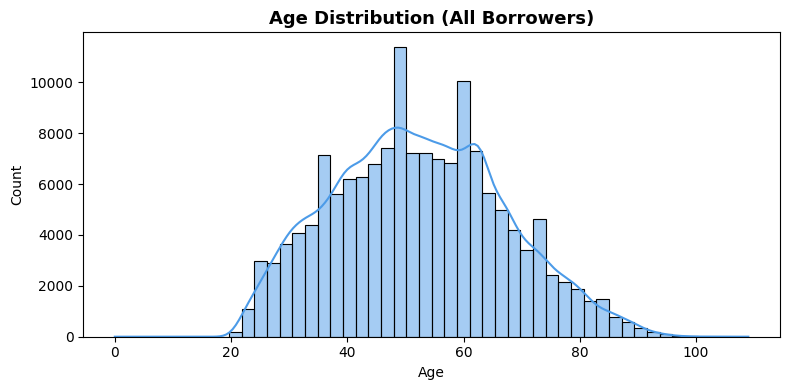

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_train["age"], kde=True, bins=50, color="#4C9BE8", ax=ax)
ax.set_title("Age Distribution (All Borrowers)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

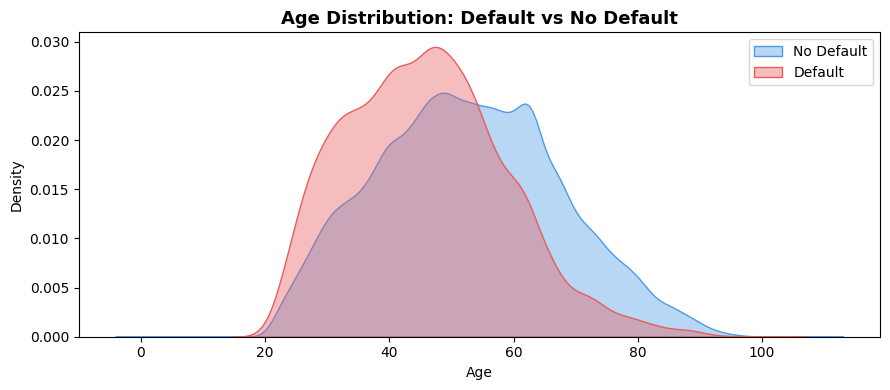

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(df_train.loc[df_train["SeriousDlqin2yrs"] == 0]["age"],
            label="No Default", fill=True, alpha=0.4, color="#4C9BE8", ax=ax)
sns.kdeplot(df_train.loc[df_train["SeriousDlqin2yrs"] == 1]["age"],
            label="Default", fill=True, alpha=0.4, color="#E85C5C", ax=ax)
ax.set_title("Age Distribution: Default vs No Default", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
late_pay_cols = ["NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTime30-59DaysPastDueNotWorse"]
df_train["NumberOfTimes90DaysLate"].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

In [26]:
df_train["NumberOfTime60-89DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [27]:
df_train["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [28]:
df_train.loc[df_train["NumberOfTimes90DaysLate"] > 17][late_pay_cols].describe()

,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTime30-59DaysPastDueNotWorse
count,269.000000,269.000000,269.000000
mean,97.962825,97.962825,97.962825
std,0.270628,0.270628,0.270628
min,96.000000,96.000000,96.000000
25%,98.000000,98.000000,98.000000
50%,98.000000,98.000000,98.000000
75%,98.000000,98.000000,98.000000
max,98.000000,98.000000,98.000000


In [29]:
distinct_triples_counts = dict()
for arr in df_train.loc[df_train["NumberOfTimes90DaysLate"] > 17][late_pay_cols].values:
    triple = ",".join(list(map(str, arr)))
    if triple not in distinct_triples_counts:
        distinct_triples_counts[triple] = 0
    else:
        distinct_triples_counts[triple] += 1
distinct_triples_counts

{'98,98,98': 263, '96,96,96': 4}

In [30]:
df_train["DebtRatio"].describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

In [31]:
df_train["DebtRatio"].quantile(0.95)

np.float64(2449.0)

In [32]:
df_train.loc[df_train["DebtRatio"] > df_train["DebtRatio"].quantile(0.95)][["DebtRatio", "MonthlyIncome", "SeriousDlqin2yrs"]].describe()

,DebtRatio,MonthlyIncome,SeriousDlqin2yrs
count,7494.000000,379.000000,7494.000000
mean,4417.958367,0.084433,0.055111
std,7875.314649,0.278403,0.228212
min,2450.000000,0.000000,0.000000
25%,2893.250000,0.000000,0.000000
50%,3491.000000,0.000000,0.000000
75%,4620.000000,0.000000,0.000000
max,329664.000000,1.000000,1.000000


In [33]:
len(df_train[(df_train["DebtRatio"] > df_train["DebtRatio"].quantile(0.95)) & (df_train['SeriousDlqin2yrs'] == df_train['MonthlyIncome'])])

331

In [34]:
df_train.loc[df_train["DebtRatio"] > df_train["DebtRatio"].quantile(0.95)]["MonthlyIncome"].value_counts()

MonthlyIncome
0.0    347
1.0     32
Name: count, dtype: int64

In [35]:
print("Number of people who owe around 2449 or more times what they own and have same values for MonthlyIncome and SeriousDlqin2yrs: {}"\
     .format(len(df_train.loc[(df_train["DebtRatio"] > df_train["DebtRatio"].quantile(0.95)) & (df_train["MonthlyIncome"] == df_train["SeriousDlqin2yrs"])])))

Number of people who owe around 2449 or more times what they own and have same values for MonthlyIncome and SeriousDlqin2yrs: 331


<Axes: xlabel='NumberRealEstateLoansOrLines', ylabel='count'>

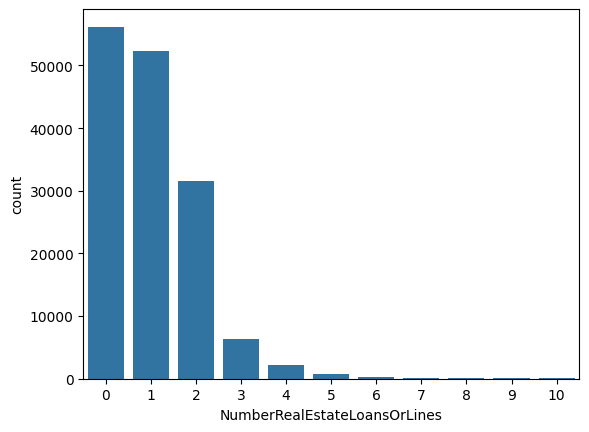

In [36]:
sns.countplot(x="NumberRealEstateLoansOrLines", data=df_train.loc[df_train["NumberRealEstateLoansOrLines"] <= 10])

In [37]:
df_train = df_train.fillna(df_train.median())
print(df_train.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [38]:
age_bins = [-math.inf, 25, 40, 50, 60, 70, math.inf]
df_train['bin_age'] = pd.cut(df_train['age'],bins=age_bins).astype(str)
dependent_bin = [-math.inf,2,4,6,8,10,math.inf]
df_train['bin_NumberOfDependents'] = pd.cut(df_train['NumberOfDependents'],bins=dependent_bin).astype(str)
dpd_bins = [-math.inf,1,2,3,4,5,6,7,8,9,math.inf]
df_train['bin_NumberOfTimes90DaysLate'] = pd.cut(df_train['NumberOfTimes90DaysLate'],bins=dpd_bins)
df_train['bin_NumberOfTime30-59DaysPastDueNotWorse'] = pd.cut(df_train['NumberOfTime30-59DaysPastDueNotWorse'], bins=dpd_bins)
df_train['bin_NumberOfTime60-89DaysPastDueNotWorse'] = pd.cut(df_train['NumberOfTime60-89DaysPastDueNotWorse'], bins=dpd_bins)


df_train['bin_RevolvingUtilizationOfUnsecuredLines'] = pd.qcut(df_train['RevolvingUtilizationOfUnsecuredLines'],q=5,duplicates='drop').astype(str)
df_train['bin_DebtRatio'] = pd.qcut(df_train['DebtRatio'],q=5,duplicates='drop').astype(str)
df_train['bin_MonthlyIncome'] = pd.qcut(df_train['MonthlyIncome'],q=5,duplicates='drop').astype(str)
df_train['bin_NumberOfOpenCreditLinesAndLoans'] = pd.qcut(df_train['NumberOfOpenCreditLinesAndLoans'],q=5,duplicates='drop').astype(str)
df_train['bin_NumberRealEstateLoansOrLines'] = pd.qcut(df_train['NumberRealEstateLoansOrLines'],q=5,duplicates='drop').astype(str)

In [39]:
bin_cols = [c for c in df_train.columns.values if c.startswith('bin_')]

In [40]:
def cal_IV(df, feature, target):
    lst = []
    cols=['Variable', 'Value', 'All', 'Bad']
    for i in range(df[feature].nunique()):
        
        val = list(df[feature].unique())[i]
        lst.append([feature, val, df[df[feature] == val].count()[feature], df[(df[feature] == val) & (df[target] == 1)].count()[feature]])
#     print(lst)
    data = pd.DataFrame(lst, columns=cols)
    data = data[data['Bad'] > 0]

    data['Share'] = data['All'] / data['All'].sum()
    data['Bad Rate'] = data['Bad'] / data['All']
    data['Distribution Good'] = (data['All'] - data['Bad']) / (data['All'].sum() - data['Bad'].sum())
    data['Distribution Bad'] = data['Bad'] / data['Bad'].sum()
    data['WoE'] = np.log(data['Distribution Bad'] / data['Distribution Good'])
    data['IV'] = (data['WoE'] * (data['Distribution Bad'] - data['Distribution Good'])).sum()

    data = data.sort_values(by=['Variable', 'Value'], ascending=True)

    return data['IV'].values[0]

In [41]:
for f in bin_cols:
    print(f)
    print(cal_IV(df_train,f,'SeriousDlqin2yrs'))

bin_age
0.24041120302785982
bin_NumberOfDependents
0.01450836007644442
bin_NumberOfTimes90DaysLate
0.49160685733515563
bin_NumberOfTime30-59DaysPastDueNotWorse
0.492444774570198
bin_NumberOfTime60-89DaysPastDueNotWorse
0.2665587583516951
bin_RevolvingUtilizationOfUnsecuredLines
1.0596188771423887
bin_DebtRatio
0.05948761145809681
bin_MonthlyIncome
0.05623446147714756
bin_NumberOfOpenCreditLinesAndLoans
0.04802315528985505
bin_NumberRealEstateLoansOrLines
0.0120914141106244


In [42]:
def cal_WOE(df,features,target):
    df_new = df
    for f in features:
        df_woe = df_new.groupby(f).agg({target:['sum','count']})
        df_woe.columns = list(map(''.join, df_woe.columns.values))
        df_woe = df_woe.reset_index()
        df_woe = df_woe.rename(columns = {target+'sum':'bad'})
        df_woe = df_woe.rename(columns = {target+'count':'all'})
        df_woe['good'] = df_woe['all']-df_woe['bad']
        df_woe = df_woe[[f,'good','bad']]
        df_woe['bad_rate'] = df_woe['bad'].mask(df_woe['bad']==0, 1)/df_woe['bad'].sum() # mask 0 to 1 to avoid log(0)
        df_woe['good_rate'] = df_woe['good']/df_woe['good'].sum()
        
        df_woe['woe'] = np.log(df_woe['bad_rate'].divide(df_woe['good_rate'],fill_value=1))
        df_woe.columns = [c if c==f else c+'_'+f for c in list(df_woe.columns.values)]
        df_new = df_new.merge(df_woe,on=f,how='left')
    return df_new

In [43]:
feature_cols = ['RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse','age','NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse']
bin_cols = ['bin_RevolvingUtilizationOfUnsecuredLines','bin_NumberOfTime30-59DaysPastDueNotWorse','bin_age','bin_NumberOfTimes90DaysLate','bin_NumberOfTime60-89DaysPastDueNotWorse']
df_woe = cal_WOE(df_train,bin_cols,'SeriousDlqin2yrs')
woe_cols = [c for c in list(df_woe.columns.values) if 'woe' in c]
df_woe[woe_cols]

,woe_bin_RevolvingUtilizationOfUnsecuredLines,woe_bin_NumberOfTime30-59DaysPastDueNotWorse,woe_bin_age,woe_bin_NumberOfTimes90DaysLate,woe_bin_NumberOfTime60-89DaysPastDueNotWorse
0,1.242254,1.616726,0.228343,-0.176674,-0.09799
1,1.242254,-0.257826,0.469547,-0.176674,-0.09799
2,0.053164,-0.257826,0.469547,-0.176674,-0.09799
3,-0.866502,-0.257826,0.469547,-0.176674,-0.09799
4,1.242254,-0.257826,0.228343,-0.176674,-0.09799
...,...,...,...,...,...
149995,-1.447382,-0.257826,-1.132145,-0.176674,-0.09799
149996,0.053164,-0.257826,0.228343,-0.176674,-0.09799
149997,-0.866502,-0.257826,-0.084782,-0.176674,-0.09799
149998,-1.286617,-0.257826,0.469547,-0.176674,-0.09799


In [44]:
df_bin_to_woe = pd.DataFrame(columns = ['features','bin','woe'])
for f in feature_cols:
    b = 'bin_'+f
    w = 'woe_bin_'+f
    df = df_woe[[w,b]].drop_duplicates()
    df.columns = ['woe','bin']
    df['features'] = f
    df=df[['features','bin','woe']]
    df_bin_to_woe = pd.concat([df_bin_to_woe,df])
df_bin_to_woe

,features,bin,woe
0,RevolvingUtilizationOfUnsecuredLines,"(0.699, 50708.0]",1.242254
2,RevolvingUtilizationOfUnsecuredLines,"(0.271, 0.699]",0.053164
3,RevolvingUtilizationOfUnsecuredLines,"(0.0832, 0.271]",-0.866502
11,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.0192]",-1.286617
14,RevolvingUtilizationOfUnsecuredLines,"(0.0192, 0.0832]",-1.447382
0,NumberOfTime30-59DaysPastDueNotWorse,"(1.0, 2.0]",1.616726
1,NumberOfTime30-59DaysPastDueNotWorse,"(-inf, 1.0]",-0.257826
13,NumberOfTime30-59DaysPastDueNotWorse,"(2.0, 3.0]",2.027495
183,NumberOfTime30-59DaysPastDueNotWorse,"(3.0, 4.0]",2.336869
191,NumberOfTime30-59DaysPastDueNotWorse,"(4.0, 5.0]",2.436786


In [45]:
X_train, X_test, y_train, y_test = train_test_split(df_woe[woe_cols], df_woe['SeriousDlqin2yrs'], test_size=0.2, random_state=42)

In [46]:
print('bad rate is: ',y_train.mean())

bad rate is:  0.06725


In [47]:
X_train.describe()

,woe_bin_RevolvingUtilizationOfUnsecuredLines,woe_bin_NumberOfTime30-59DaysPastDueNotWorse,woe_bin_age,woe_bin_NumberOfTimes90DaysLate,woe_bin_NumberOfTime60-89DaysPastDueNotWorse
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,-0.460494,-0.143652,-0.112757,-0.114278,-0.062802
std,0.998029,0.487847,0.539645,0.432243,0.315584
min,-1.447382,-0.257826,-1.132145,-0.176674,-0.097990
25%,-1.286617,-0.257826,-0.689003,-0.176674,-0.097990
50%,-0.866502,-0.257826,-0.084782,-0.176674,-0.097990
75%,0.053164,-0.257826,0.228343,-0.176674,-0.097990
max,1.242254,2.846431,0.562024,4.124352,3.734887


In [48]:
model = LogisticRegression(random_state=42).fit(X_train,y_train)

In [49]:
model.score(X_test,y_test)

0.9370333333333334

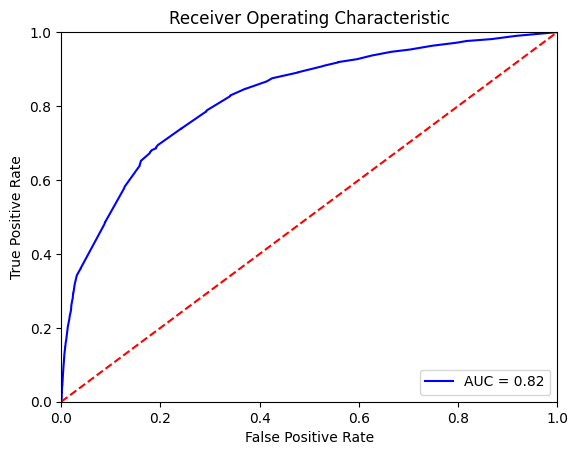

In [50]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
probs = model.predict_proba(X_test)

preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

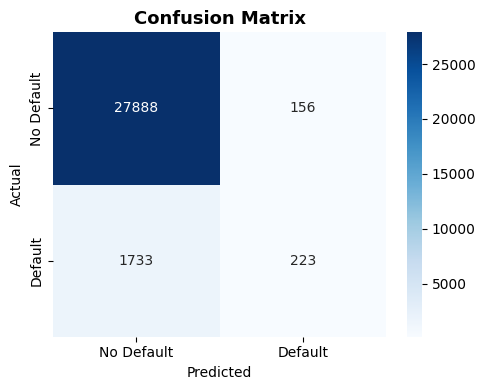

              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     28044
     Default       0.59      0.11      0.19      1956

    accuracy                           0.94     30000
   macro avg       0.76      0.55      0.58     30000
weighted avg       0.92      0.94      0.92     30000



In [51]:
y_pred = model.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

print(metrics.classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

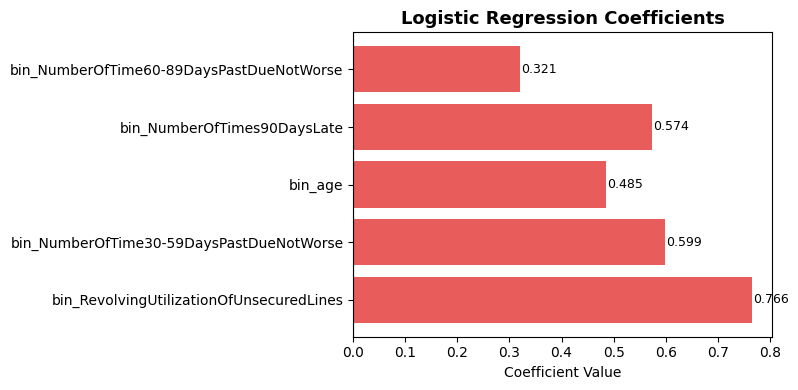

In [52]:
feature_labels = [c.replace("woe_", "") for c in woe_cols]
coef_values = model.coef_[0]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E85C5C" if v > 0 else "#4C9BE8" for v in coef_values]
bars = ax.barh(feature_labels, coef_values, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Logistic Regression Coefficients", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")
for bar, val in zip(bars, coef_values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

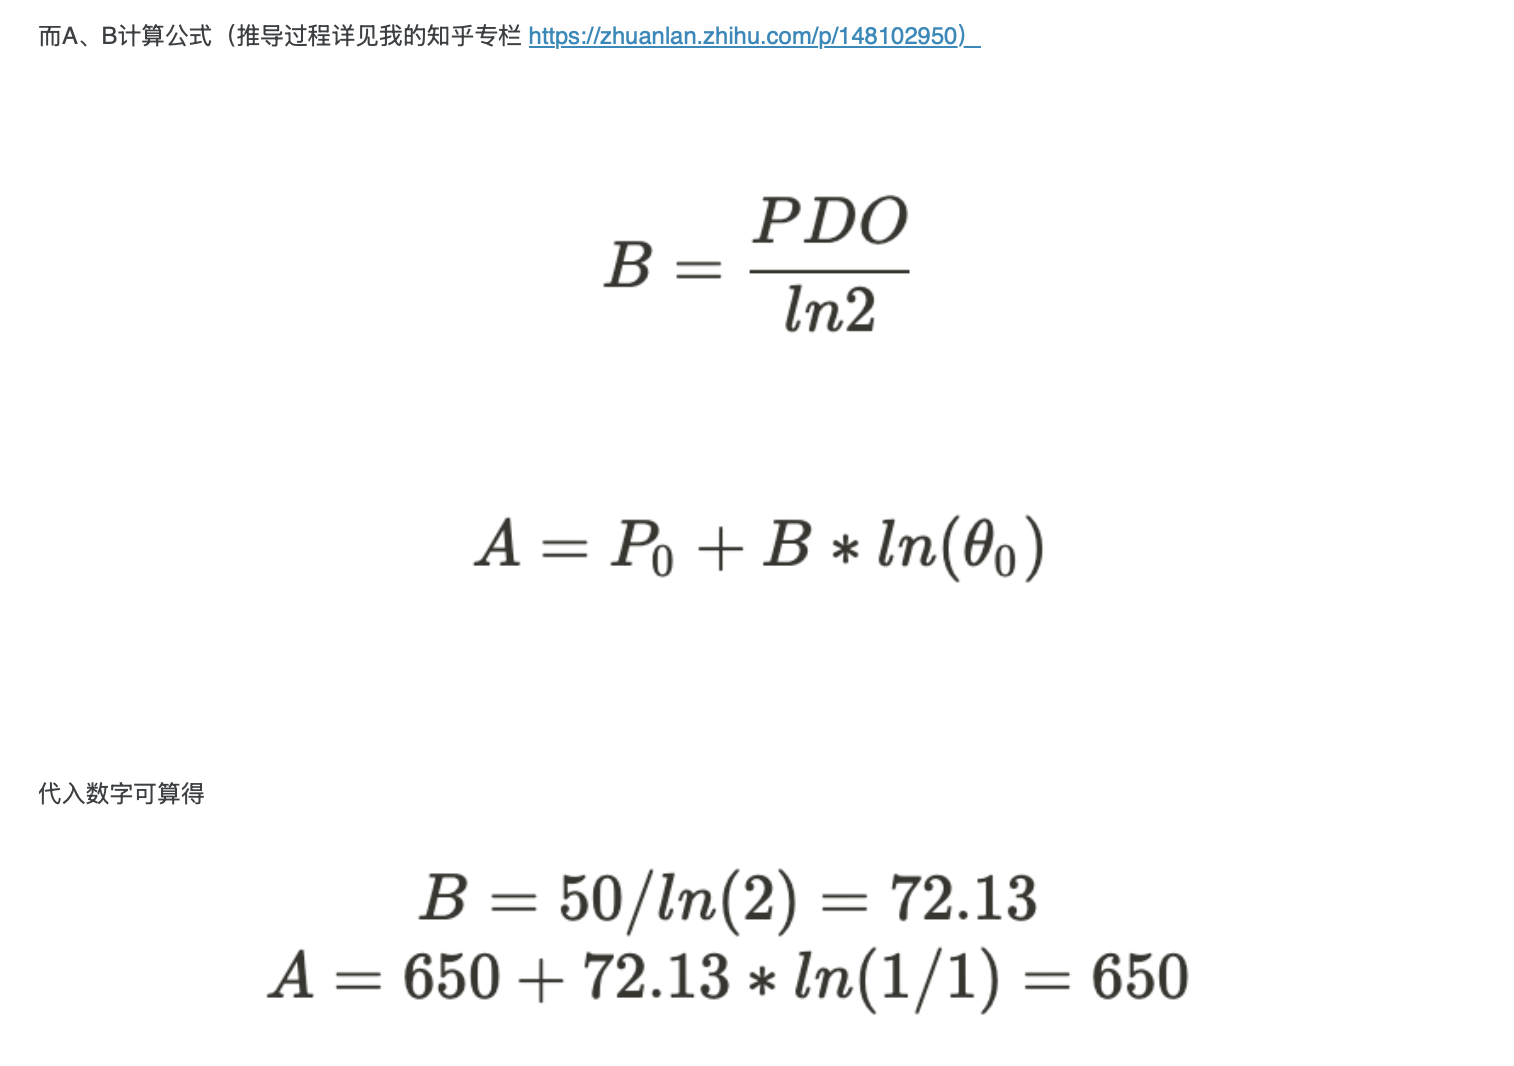

In [53]:
A = 650
B = 72.13

In [54]:
def generate_scorecard(model_coef,binning_df,features,B):
    lst = []
    cols = ['Variable','Binning','Score']
    coef = model_coef[0]
    for i in range(len(features)):
        f = features[i]
        df = binning_df[binning_df['features']==f]
        for index,row in df.iterrows():
            lst.append([f,row['bin'],int(round(-coef[i]*row['woe']*B))])
    data = pd.DataFrame(lst, columns=cols)
    return data

                            Variable          Binning  Score
RevolvingUtilizationOfUnsecuredLines (0.699, 50708.0]    -69
RevolvingUtilizationOfUnsecuredLines   (0.271, 0.699]     -3
RevolvingUtilizationOfUnsecuredLines  (0.0832, 0.271]     48
RevolvingUtilizationOfUnsecuredLines (-0.001, 0.0192]     71
RevolvingUtilizationOfUnsecuredLines (0.0192, 0.0832]     80
NumberOfTime30-59DaysPastDueNotWorse       (1.0, 2.0]    -70
NumberOfTime30-59DaysPastDueNotWorse      (-inf, 1.0]     11
NumberOfTime30-59DaysPastDueNotWorse       (2.0, 3.0]    -88
NumberOfTime30-59DaysPastDueNotWorse       (3.0, 4.0]   -101
NumberOfTime30-59DaysPastDueNotWorse       (4.0, 5.0]   -105
NumberOfTime30-59DaysPastDueNotWorse       (6.0, 7.0]   -117
NumberOfTime30-59DaysPastDueNotWorse       (9.0, inf]   -123
NumberOfTime30-59DaysPastDueNotWorse       (5.0, 6.0]   -119
NumberOfTime30-59DaysPastDueNotWorse       (7.0, 8.0]    -81
NumberOfTime30-59DaysPastDueNotWorse       (8.0, 9.0]    -84
                        

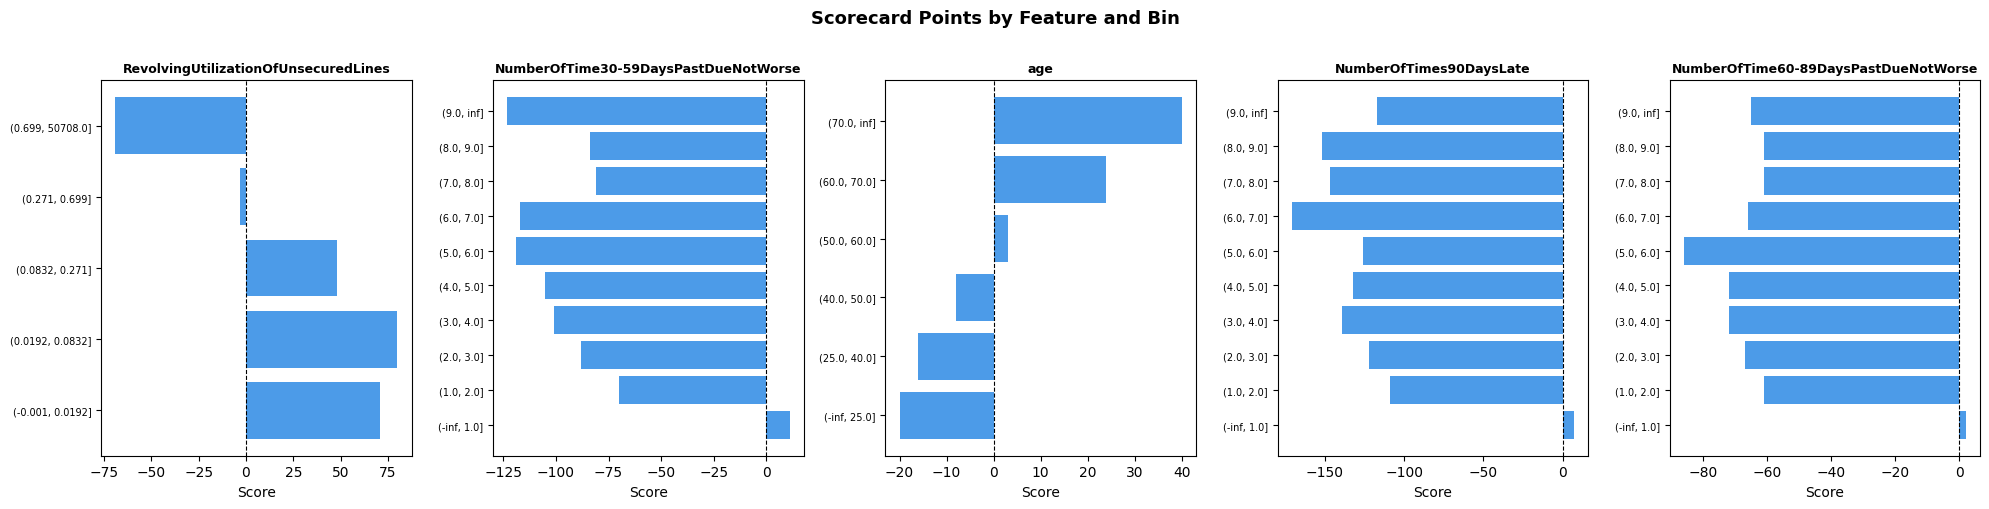

In [55]:
scorecard = generate_scorecard(model.coef_, df_bin_to_woe, feature_cols, B)
print(scorecard.to_string(index=False))

# Визуализация скоркарты
fig, axes = plt.subplots(1, len(feature_cols), figsize=(4 * len(feature_cols), 5), sharey=False)
for ax, feat in zip(axes, feature_cols):
    sub = scorecard[scorecard["Variable"] == feat].sort_values("Binning")
    ax.barh(sub["Binning"].astype(str), sub["Score"], color="#4C9BE8")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.set_xlabel("Score")
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("Scorecard Points by Feature and Bin", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Переобучение модели с расширенным набором признаков (включая доход и долговую нагрузку)

In [57]:
# Расширенный набор признаков с доходом и долговой нагрузкой
feature_cols_extended = [
    'RevolvingUtilizationOfUnsecuredLines',  # Использование кредитного лимита
    'NumberOfTime30-59DaysPastDueNotWorse',  # Просрочки 30-59 дней
    'age',                                    # Возраст
    'NumberOfTimes90DaysLate',               # Просрочки 90+ дней
    'NumberOfTime60-89DaysPastDueNotWorse',  # Просрочки 60-89 дней
    'MonthlyIncome',                          # Ежемесячный доход
    'DebtRatio',                              # Долговая нагрузка (долг/доход)
]

bin_cols_extended = [
    'bin_RevolvingUtilizationOfUnsecuredLines',
    'bin_NumberOfTime30-59DaysPastDueNotWorse',
    'bin_age',
    'bin_NumberOfTimes90DaysLate',
    'bin_NumberOfTime60-89DaysPastDueNotWorse',
    'bin_MonthlyIncome',
    'bin_DebtRatio',
]

# Пересчитываем WoE для расширенного набора
df_woe_extended = cal_WOE(df_train, bin_cols_extended, 'SeriousDlqin2yrs')
woe_cols_extended = [c for c in df_woe_extended.columns if 'woe' in c]

print("Расширенный набор WoE-признаков:")
print(woe_cols_extended)
print(f"\nКоличество признаков: {len(woe_cols_extended)}")

Расширенный набор WoE-признаков:
['woe_bin_RevolvingUtilizationOfUnsecuredLines', 'woe_bin_NumberOfTime30-59DaysPastDueNotWorse', 'woe_bin_age', 'woe_bin_NumberOfTimes90DaysLate', 'woe_bin_NumberOfTime60-89DaysPastDueNotWorse', 'woe_bin_MonthlyIncome', 'woe_bin_DebtRatio']

Количество признаков: 7


Accuracy на тесте: 0.9368
AUC-ROC: 0.8268


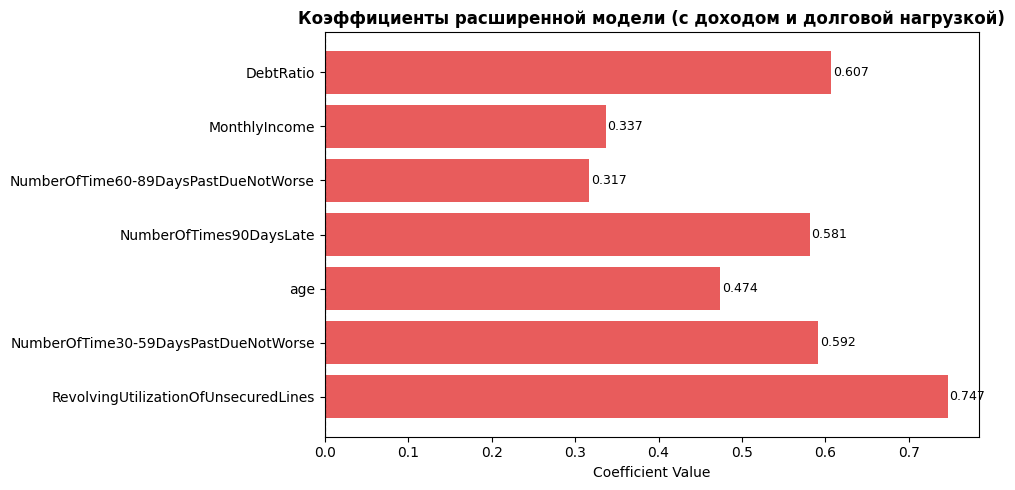

In [58]:
# Обучаем расширенную модель
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    df_woe_extended[woe_cols_extended], 
    df_woe_extended['SeriousDlqin2yrs'], 
    test_size=0.2, 
    random_state=42
)

model_extended = LogisticRegression(random_state=42, max_iter=1000).fit(X_train_ext, y_train_ext)

print(f"Accuracy на тесте: {model_extended.score(X_test_ext, y_test_ext):.4f}")

# ROC-AUC
probs_ext = model_extended.predict_proba(X_test_ext)[:, 1]
fpr_ext, tpr_ext, _ = metrics.roc_curve(y_test_ext, probs_ext)
roc_auc_ext = metrics.auc(fpr_ext, tpr_ext)
print(f"AUC-ROC: {roc_auc_ext:.4f}")

# Визуализация коэффициентов
feature_labels_ext = [c.replace("woe_bin_", "") for c in woe_cols_extended]
coef_ext = model_extended.coef_[0]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E85C5C" if v > 0 else "#4C9BE8" for v in coef_ext]
bars = ax.barh(feature_labels_ext, coef_ext, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Коэффициенты расширенной модели (с доходом и долговой нагрузкой)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
for bar, val in zip(bars, coef_ext):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

In [59]:
import joblib
import json

# Сохраняем расширенную модель
joblib.dump(model_extended, 'model.pkl')

# Создаём таблицу WoE для расширенного набора признаков
df_bin_to_woe_ext = pd.DataFrame(columns=['features', 'bin', 'woe'])
for f in feature_cols_extended:
    b = 'bin_' + f
    w = 'woe_bin_' + f
    df_temp = df_woe_extended[[w, b]].drop_duplicates()
    df_temp.columns = ['woe', 'bin']
    df_temp['features'] = f
    df_temp = df_temp[['features', 'bin', 'woe']]
    df_bin_to_woe_ext = pd.concat([df_bin_to_woe_ext, df_temp])

df_bin_to_woe_ext.to_csv('woe_mapping.csv', index=False)

# Сохраняем границы бинов
bin_edges = {
    'age': [-float('inf'), 25, 40, 50, 60, 70, float('inf')],
    'NumberOfTimes90DaysLate': [-float('inf'), 1, 2, 3, 4, 5, 6, 7, 8, 9, float('inf')],
    'NumberOfTime30-59DaysPastDueNotWorse': [-float('inf'), 1, 2, 3, 4, 5, 6, 7, 8, 9, float('inf')],
    'NumberOfTime60-89DaysPastDueNotWorse': [-float('inf'), 1, 2, 3, 4, 5, 6, 7, 8, 9, float('inf')],
}

# Квантили для непрерывных признаков
ruul_q = df_train['RevolvingUtilizationOfUnsecuredLines'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).tolist()
bin_edges['RevolvingUtilizationOfUnsecuredLines'] = ruul_q

income_q = df_train['MonthlyIncome'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).tolist()
bin_edges['MonthlyIncome'] = income_q

debt_q = df_train['DebtRatio'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).tolist()
bin_edges['DebtRatio'] = debt_q

with open('bin_edges.json', 'w') as f:
    json.dump(bin_edges, f)

# Сохраняем feature_cols
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols_extended, f)

# Генерируем и сохраняем скоркарту
scorecard_ext = generate_scorecard(model_extended.coef_, df_bin_to_woe_ext, feature_cols_extended, B)
scorecard_ext.to_csv('scorecard.csv', index=False)

print("✅ Расширенная модель и артефакты сохранены:")
print("- model.pkl (7 признаков вместо 5)")
print("- woe_mapping.csv")
print("- bin_edges.json")
print("- feature_cols.json")
print("- scorecard.csv")
print(f"\n📊 Признаки модели: {feature_cols_extended}")

✅ Расширенная модель и артефакты сохранены:
- model.pkl (7 признаков вместо 5)
- woe_mapping.csv
- bin_edges.json
- feature_cols.json
- scorecard.csv

📊 Признаки модели: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'MonthlyIncome', 'DebtRatio']
